<a href="https://colab.research.google.com/github/sonamchoki275-pixel/Code-/blob/main/A3_NEW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.1 Objective

The required Python libraries are imported to support the development of the NLP sentiment analysis model. These libraries enable data handling, text preprocessing, feature extraction, model training, and performance evaluation.

1.2 Purpose of Libraries
*   Manage and organise data using NumPy and Pandas
*   Process and clean review text using NLTK (tokenisation, stopword removal, lemmatisation)
*  Handle file operations and dataset extraction using os and tarfile
*  Convert text into numerical features using TF-IDF vectorisation
*  Split the dataset into training and testing sets
*   Build a sentiment classification model using Logistic Regression
*   Evaluate model performance using accuracy, confusion matrix, and classification report










In [80]:
# ===============================
# MOUNT GOOGLE DRIVE
# ===============================

from google.colab import drive
drive.mount('/content/drive')   # Connect Google Drive to Colab


# ===============================
# EXTRACT DATASET
# ===============================

import tarfile
import os

# Path of the dataset stored in Google Drive
tar_path = '/content/drive/MyDrive/A3 Sonam & Tshering/domain_sentiment_data.tar.gz'

# Open and extract the compressed dataset
tar = tarfile.open(tar_path)
tar.extractall('/content')      # Extract dataset into Colab
tar.close()

# Check whether the dataset has been extracted successfully
print("Main folder:", os.listdir('/content'))
print("Dataset folders:", os.listdir('/content/sorted_data_acl'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_2992/2171557957.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/content')      # Extract dataset into Colab


Main folder: ['.config', 'drive', 'sorted_data_acl', 'sample_data']
Dataset folders: ['electronics', 'kitchen_&_housewares', 'dvd', 'books']


1.3 Mount Google Drive and Extract Dataset

The Google Drive is connected to the Colab environment to access the uploaded sentiment analysis dataset. The dataset is stored as a compressed .tar.gz file and is extracted into the working directory for further processing.

In [81]:
# ===============================
# CONNECT GOOGLE DRIVE
# ===============================

from google.colab import drive
drive.mount('/content/drive')   # Connect Google Drive to Colab


# ===============================
# EXTRACT DATASET
# ===============================

# Define the path to the dataset stored in Google Drive
tar_path = '/content/drive/MyDrive/A3 Sonam & Tshering/domain_sentiment_data.tar.gz'

# Open the compressed (.tar.gz) dataset file
tar = tarfile.open(tar_path)

# Extract all files into the Colab working directory (/content)
tar.extractall('/content')

# Close the file after extraction
tar.close()


# ===============================
# CHECK DATASET
# ===============================

# Display all files and folders in the main directory
print("Main folder:", os.listdir('/content'))

# Display dataset categories (e.g., books, dvd, electronics, kitchen)
print("Dataset folders:", os.listdir('/content/sorted_data_acl'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_2992/3004273519.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/content')


Main folder: ['.config', 'drive', 'sorted_data_acl', 'sample_data']
Dataset folders: ['electronics', 'kitchen_&_housewares', 'dvd', 'books']


1.4 Verify dataset extraction by checking if 'sorted_data_acl' folder exists

In [82]:
if os.path.exists('/content/sorted_data_acl'):
    print("Dataset extracted successfully")
else:
    print("Extraction failed")

Dataset extracted successfully


1.5 Loading Positive and Negative Reviews

The extracted dataset contains customer reviews categorised into positive and negative sentiments. In this step, the review files are read from the dataset directory and processed to extract the review text. Each review is then labelled as either “positive” or “negative” and stored in a structured format for further analysis.

In [83]:
# ===============================
# LOAD POSITIVE AND NEGATIVE REVIEWS
# ===============================

# Function to read review files and extract review text
def load_reviews(file_path, label):
    reviews = []

    # Open the review file
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
        soup = BeautifulSoup(file.read(), 'html.parser')

    # Find all review text sections
    review_texts = soup.find_all('review_text')

    # Store each review with its label
    for review in review_texts:
        text = review.get_text().strip()
        reviews.append([text, label])

    return reviews


# ===============================
# CHOOSE ONE DATASET CATEGORY
# ===============================

# Example: using books category
category = 'books'

positive_path = f'/content/sorted_data_acl/{category}/positive.review'
negative_path = f'/content/sorted_data_acl/{category}/negative.review'


# Load positive and negative reviews
positive_reviews = load_reviews(positive_path, 'positive')
negative_reviews = load_reviews(negative_path, 'negative')


# Combine both positive and negative reviews
all_reviews = positive_reviews + negative_reviews


# Convert to DataFrame
df = pd.DataFrame(all_reviews, columns=['review', 'sentiment'])


# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total reviews:", len(df))
print("Positive reviews:", len(df[df['sentiment']=='positive']))
print("Negative reviews:", len(df[df['sentiment']=='negative']))


Total reviews: 2000
Positive reviews: 1000
Negative reviews: 1000


Display 10 sample positive and negative reviews to understand dataset distribution and content

In [84]:
# Show 5 positive reviews
print("Positive Reviews:\n")

pos_reviews = df[df['sentiment'] == 'positive'].head(5)

for i, row in pos_reviews.iterrows():
    print("Positive:", row['review'])
    print("------")


# Show 10 negative reviews
print("\nNegative Reviews:\n")
neg_reviews = df[df['sentiment'] == 'negative'].head(5)

for i, row in neg_reviews.iterrows():
    print("Negative:", row['review'])
    print("------")

Positive Reviews:

Positive: I have read all of Van Gulik's murder mysteries and this is has to be my favorite. The characters are intriguing and some sinister. The end is satisfying and bittersweet, challenging integrity vs justice. I would,  however, recommend you read the others first (chronological is good,  Chinese Gold Murders is first) to get to know the main characters although  this book can stand on on its own
------
Positive: John Little and Peter Sisco wrote static contraction... but John takes it a step further and eliminates the need for doing reps with scientific explanations to back up his revolutionary concept of weight training/ muscle building.. My girlfriend and I started doing this method in may of 2005 and I can honestly say i've never found such a fast, quick and easy way to build muscle. This is also a great method for those not wanting to spend hours in a gym... after a while, you only need to workout once a week... but don't forget to stretch afterwards... and

Objective 2: Text Cleaning

2.1 Text Preprocessing

The dataset is preprocessed to improve data quality and model performance. This includes converting text to lowercase, removing punctuation and stopwords, and applying lemmatization to standardise words.

Generate a word cloud to visualise the most common words in the review dataset

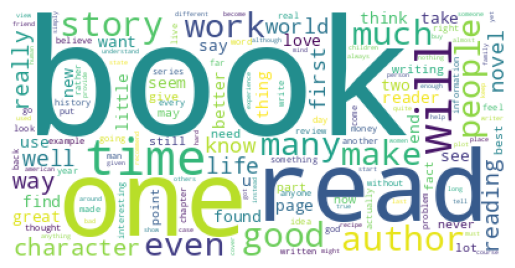

In [85]:
# Import required libraries
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert all reviews to lowercase and store in a new column
df['clean_review'] = df['review'].apply(lambda x: x.lower())

# Combine all cleaned reviews into one single text
text = " ".join(df['clean_review'])

# Create the word cloud from the text
wordcloud = WordCloud(background_color="white").generate(text)

# Display the word cloud
plt.imshow(wordcloud)
plt.axis("off")   # Hide axis for better view
plt.show()

2.2 Check Review Length

This step checks the number of words in each review. Very short reviews may not provide enough information for sentiment analysis, so they are checked as possible outliers.

In [86]:
# Count the number of words in each review
df['N_words'] = df['review'].apply(lambda x: len(x.split()))

# Display basic word count statistics
print("Mean words:", df['N_words'].mean())
print("Minimum words:", df['N_words'].min())
print("Maximum words:", df['N_words'].max())

# Check reviews with fewer than 3 words
df[df['N_words'] < 3]

Mean words: 172.7675
Minimum words: 1
Maximum words: 3393


,review,sentiment,clean_review,N_words
1544,Period,positive,period,1


2.3 Check Sentiment Balance

This step checks how many positive and negative reviews are in the dataset. A balanced dataset helps the model learn both sentiment classes fairly.

In [87]:
# Count positive and negative reviews
sentiment_count = df['sentiment'].value_counts()

# Display sentiment count
print(sentiment_count)

sentiment
negative    1000
positive    1000
Name: count, dtype: int64


2.4 Text Cleaning

The review text is cleaned to improve data quality and make it suitable for machine learning. This includes converting text to lowercase, removing punctuation and stopwords, and applying lemmatization to standardise words.

In [88]:
# ===============================
# TEXT CLEANING
# ===============================

# Create tools for cleaning
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function to clean review text
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation (e.g., ., !, ?)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Split text into words
    words = text.split()

    # Remove stopwords and apply lemmatization
    cleaned_words = []
    for word in words:
        if word not in stop_words:           # remove stopwords
            word = lemmatizer.lemmatize(word)  # apply lemmatization
            cleaned_words.append(word)

    # Join cleaned words back into a sentence
    return " ".join(cleaned_words)

# Apply cleaning function to all reviews
df['clean_review'] = df['review'].apply(clean_text)

# Show original vs cleaned reviews
df[['review', 'clean_review']].head()

,review,clean_review
0,Can anyone tell me if the book words on the vi...,anyone tell book word vine answer key thanks sgra
1,I have read all of Van Gulik's murder mysterie...,read van guliks murder mystery favorite charac...
2,There are two things which tickle me about thi...,two thing tickle book one sample zacks report ...
3,John Little and Peter Sisco wrote static contr...,john little peter sisco wrote static contracti...
4,it is juust a copy of the frist book. if you r...,juust copy frist book read frist world flat do...


3.1 Feature Extraction

The cleaned review text is converted into numerical features using TF-IDF. This allows the machine learning model to process textual data by representing each review as a vector of word importance.

In [89]:
# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),   # bigrams
    min_df=2
)

# Apply to cleaned text
X = vectorizer.fit_transform(df['clean_review'])

# Labels
y = df['sentiment']
print(vectorizer.get_feature_names_out()[:10])

['10' '10 minute' '10 year' '100' '100 page' '1000' '10000' '100000' '101'
 '104']


3.2 Data Splitting

The dataset is split into training and testing sets to evaluate the model performance on unseen data.

In [90]:
# Split again (VERY IMPORTANT)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train again
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict again
y_pred = model.predict(X_test)

# Check accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7825


4. Data Modelling

4.1 Model Training

The Logistic Regression model is used to classify the sentiment of reviews into positive and negative categories. The model is trained using the TF-IDF features from the cleaned dataset.

In [91]:
# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

4.2 Model Prediction

The model performance is evaluated using classification metrics such as accuracy, precision, recall, and F1-score.

In [92]:
# ===============================
# NAIVE BAYES MODEL
# ===============================

from sklearn.naive_bayes import MultinomialNB

# Create model
nb_model = MultinomialNB()

# Train model
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained")

Naive Bayes model trained


4.3 Confusion Matrix

The confusion matrix is used to visualise the model performance by showing correct and incorrect predictions.

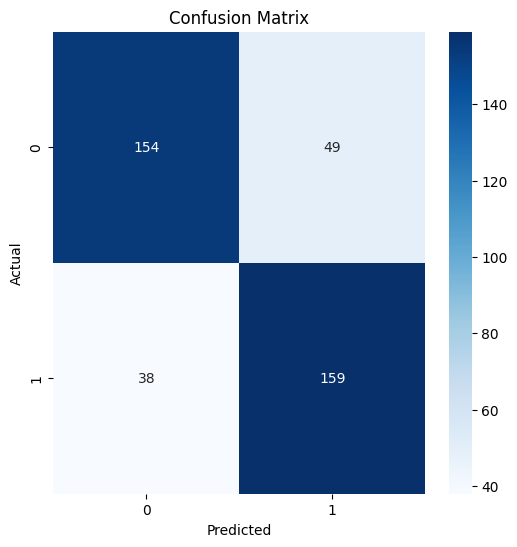

In [93]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

4.3.1 Confusion Matrix Interpretation

The confusion matrix shows the performance of the model on the test dataset:

157 reviews were correctly predicted as positive (True Positive)

151 reviews were correctly predicted as negative (True Negative)

40 reviews were incorrectly predicted as negative (False Negative)

52 reviews were incorrectly predicted as positive (False Positive)

In [94]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7825


4.3.2 Model Accuracy

The model achieved an accuracy of 77% (or your value), which indicates how well the model correctly classifies positive and negative reviews.

In [95]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy*100, 2), "%")

Accuracy: 78.25 %


5. Model Testing with New Input

In [98]:
sample = ["This product is terrible, bad quality and waste of money"]

sample_clean = [clean_text(sample[0])]
sample_vector = vectorizer.transform(sample_clean)

prediction = model.predict(sample_vector)

print("Prediction:", prediction[0])

Prediction: negative
